In [4]:
def compute_iou(heatmap, bbox, original_size=1024, target_size=320, threshold=0.2):
    """
    Compute IoU between thresholded Grad-CAM heatmap and radiologist bounding box.
    
    heatmap: numpy [320, 320] normalized 0-1
    bbox: (x, y, w, h) in original 1024x1024 coordinates
    threshold: top X% of activation becomes the predicted mask
    """
    x, y, w, h = bbox
    
    # Scale bbox from original size to target size
    scale = target_size / original_size
    x_s = int(x * scale)
    y_s = int(y * scale)
    w_s = max(1, int(w * scale))
    h_s = max(1, int(h * scale))
    
    # Create ground truth mask from bounding box
    gt_mask = np.zeros((target_size, target_size), dtype=np.uint8)
    gt_mask[y_s:y_s+h_s, x_s:x_s+w_s] = 1
    
    # Create predicted mask by thresholding heatmap
    pred_mask = (heatmap >= threshold).astype(np.uint8)
    
    # Compute IoU
    intersection = (gt_mask & pred_mask).sum()
    union = (gt_mask | pred_mask).sum()
    
    if union == 0:
        return 0.0
    
    return intersection / union

print("IoU function ready")

IoU function ready


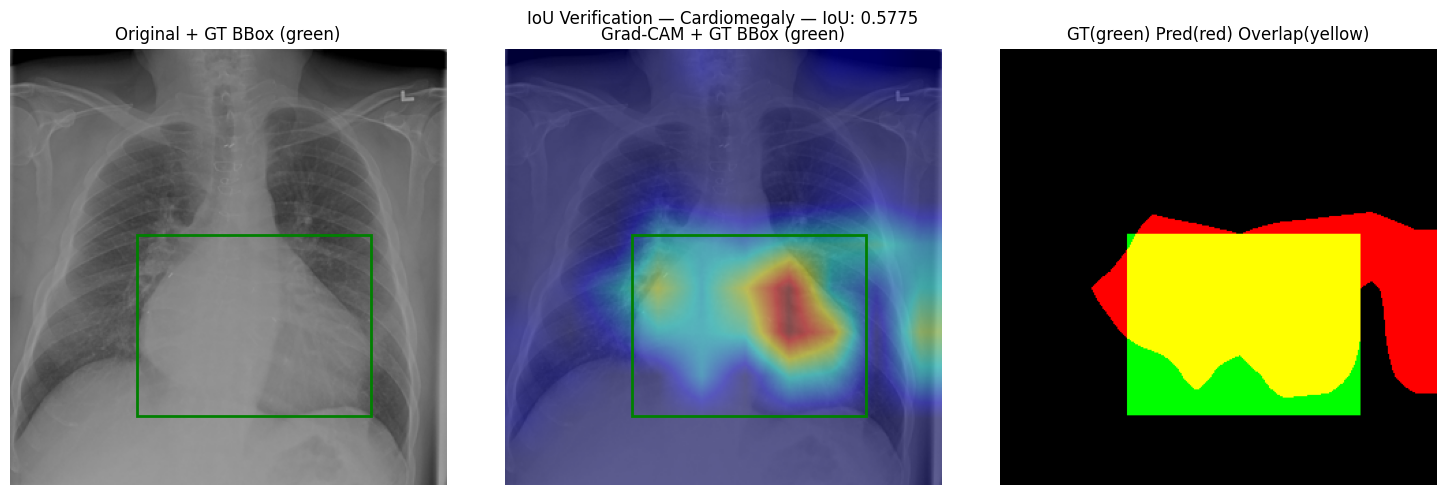

IoU: 0.5775


In [5]:
import sys
sys.path.append('D:/cxr-triage')

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image as PILImage

from src.models.densenet import DenseNetModel
from src.data.transforms import get_val_transforms
from src.inference.gradcam import GradCAM

# Config
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGE_ROOT = "F:/X ray dataset/Second Version"
CHECKPOINT_PATH = "D:/cxr-triage/checkpoints/clahe_320_logits_fix/best_model.pth"
LABELS = ['Atelectasis','Consolidation','Infiltration','Pneumothorax','Edema',
          'Emphysema','Fibrosis','Effusion','Pneumonia','Pleural_Thickening',
          'Cardiomegaly','Nodule','Mass','Hernia']

# Load model
model = DenseNetModel(num_classes=14, pretrained=False).to(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
transform = get_val_transforms(image_size=320, use_clahe=True)
gradcam = GradCAM(model)

# Load bbox data
bbox_df = pd.read_csv(f"{IMAGE_ROOT}/BBox_List_2017.csv")
bbox_df = bbox_df.rename(columns={'Bbox [x':'x','y':'y','w':'w','h]':'h'})[['Image Index','Finding Label','x','y','w','h']]
full_df = pd.read_csv(f"{IMAGE_ROOT}/Data_Entry_2017.csv")
pa_images = set(full_df[full_df['View Position']=='PA']['Image Index'])

# IoU function
def compute_iou(heatmap, bbox, original_size=1024, target_size=320, threshold=0.2):
    x, y, w, h = bbox
    heatmap_resized = cv2.resize(heatmap.astype(np.float32), (target_size, target_size))
    scale = target_size / original_size
    x_s, y_s = int(x*scale), int(y*scale)
    w_s, h_s = max(1,int(w*scale)), max(1,int(h*scale))
    gt_mask = np.zeros((target_size,target_size), dtype=np.uint8)
    gt_mask[y_s:y_s+h_s, x_s:x_s+w_s] = 1
    pred_mask = (heatmap_resized >= threshold).astype(np.uint8)
    intersection = (gt_mask & pred_mask).sum()
    union = (gt_mask | pred_mask).sum()
    return float(intersection)/float(union) if union > 0 else 0.0

# Find a PA Cardiomegaly case
cardio_bbox = bbox_df[(bbox_df['Finding Label']=='Cardiomegaly') & 
                       (bbox_df['Image Index'].isin(pa_images))].iloc[0]

# Find image
image_path = None
for folder in [f"images_{str(i).zfill(3)}" for i in range(1,13)]:
    path = f"{IMAGE_ROOT}/{folder}/images/{cardio_bbox['Image Index']}"
    if os.path.exists(path):
        image_path = path
        break

# Generate heatmap
img = PILImage.open(image_path).convert('RGB')
img_320 = np.array(img.resize((320,320)))
img_tensor = transform(img).unsqueeze(0)
heatmap = gradcam.generate(img_tensor.clone(), LABELS.index('Cardiomegaly'))
overlay, _ = gradcam.overlay(heatmap, img_320)

# Scale bbox
scale = 320/1024
x_s = int(cardio_bbox['x']*scale)
y_s = int(cardio_bbox['y']*scale)
w_s = int(cardio_bbox['w']*scale)
h_s = int(cardio_bbox['h']*scale)

# Compute IoU
iou = compute_iou(heatmap, (cardio_bbox['x'],cardio_bbox['y'],cardio_bbox['w'],cardio_bbox['h']))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(img_320, cmap='gray')
axes[0].add_patch(patches.Rectangle((x_s,y_s),w_s,h_s,linewidth=2,edgecolor='green',facecolor='none'))
axes[0].set_title('Original + GT BBox (green)')
axes[0].axis('off')

axes[1].imshow(overlay)
axes[1].add_patch(patches.Rectangle((x_s,y_s),w_s,h_s,linewidth=2,edgecolor='green',facecolor='none'))
axes[1].set_title('Grad-CAM + GT BBox (green)')
axes[1].axis('off')

gt_mask = np.zeros((320,320,3), dtype=np.uint8)
hm_resized = cv2.resize(heatmap.astype(np.float32),(320,320))
pred_mask = (hm_resized >= 0.2)
gt_box = np.zeros((320,320), dtype=bool)
gt_box[y_s:y_s+h_s, x_s:x_s+w_s] = True
rgb = np.zeros((320,320,3), dtype=np.uint8)
rgb[gt_box] = [0,255,0]
rgb[pred_mask] = [255,0,0]
rgb[gt_box & pred_mask] = [255,255,0]
axes[2].imshow(rgb)
axes[2].set_title('GT(green) Pred(red) Overlap(yellow)')
axes[2].axis('off')

plt.suptitle(f'IoU Verification — Cardiomegaly — IoU: {iou:.4f}')
plt.tight_layout()
plt.savefig('D:/cxr-triage/notebooks/iou_verification.png', dpi=150)
plt.show()
print(f"IoU: {iou:.4f}")

In [ ]:
import pandas as pd
import numpy as np
import os
from PIL import Image as PILImage
import torch
import cv2

# --- Load and merge data ---
bbox_df = pd.read_csv('F:/X ray dataset/Second Version/BBox_List_2017.csv')
bbox_df = bbox_df.rename(columns={'Bbox [x': 'x', 'y': 'y', 'w': 'w', 'h]': 'h'})[
    ['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']
]
meta_df = pd.read_csv('F:/X ray dataset/Second Version/Data_Entry_2017.csv')

bbox_df = bbox_df.merge(
    meta_df[['Image Index', 'View Position']],
    on='Image Index', how='left'
)
bbox_df = bbox_df[bbox_df['Finding Label'].isin(LABELS)].reset_index(drop=True)

# --- PILOT MODE: set to False for full run ---
PILOT = False
if PILOT:
    bbox_df = bbox_df.sample(50, random_state=42).reset_index(drop=True)

print(f"Evaluating {len(bbox_df)} bounding boxes")
print(bbox_df['Finding Label'].value_counts())
print(bbox_df['View Position'].value_counts())

# NIH ChestX-ray14 PNGs are all natively 1024x1024, regardless of
# the OriginalImage[Width/Height] metadata in Data_Entry_2017.csv
# (that metadata reflects source DICOM resolution, not the PNG on disk).
ORIGINAL_SIZE = 1024
TARGET_SIZE = 320

def compute_iou(gt_mask, pred_mask):
    intersection = np.logical_and(gt_mask, pred_mask).sum()
    union = np.logical_or(gt_mask, pred_mask).sum()
    return intersection / union if union > 0 else 0.0

PERCENTILES = [80, 90, 95]
results = []

for idx, row in bbox_df.iterrows():
    img_name = row['Image Index']
    finding = row['Finding Label']
    view = row['View Position']
    gx, gy, gw, gh = row['x'], row['y'], row['w'], row['h']

    image_path = None
    for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
        path = os.path.join(IMAGE_ROOT, folder, "images", img_name)
        if os.path.exists(path):
            image_path = path
            break
    if image_path is None:
        print(f"WARNING: image not found: {img_name}")
        continue

    img = PILImage.open(image_path).convert('RGB')

    # Sanity check — catch any future scaling assumption breakage immediately
    assert img.size == (ORIGINAL_SIZE, ORIGINAL_SIZE), \
        f"Unexpected size {img.size} for {img_name}, expected {(ORIGINAL_SIZE, ORIGINAL_SIZE)}"

    # Scale GT box from native 1024x1024 to 320x320 inference resolution
    scale = TARGET_SIZE / ORIGINAL_SIZE
    gx1, gy1 = gx * scale, gy * scale
    gx2, gy2 = (gx + gw) * scale, (gy + gh) * scale

    gt_mask = np.zeros((TARGET_SIZE, TARGET_SIZE), dtype=bool)
    gt_mask[int(gy1):int(gy2), int(gx1):int(gx2)] = True

    img_tensor = transform(img).unsqueeze(0)
    class_idx = LABELS.index(finding)

    # Model probability for this class (recognized vs unrecognized positives)
    with torch.no_grad():
        device = next(model.parameters()).device
        logits = model(img_tensor.to(device))
        prob = torch.sigmoid(logits)[0, class_idx].item()

    heatmap = gradcam.generate(img_tensor.clone(), class_idx)
    heatmap_resized = cv2.resize(heatmap.astype(np.float32), (TARGET_SIZE, TARGET_SIZE))

    row_result = {
        'Image': img_name,
        'Finding': finding,
        'View': view,
        'Probability': prob,
    }

    # IoU at multiple percentile thresholds
    for p in PERCENTILES:
        thresh = np.percentile(heatmap_resized, p)
        pred_mask = heatmap_resized >= thresh
        row_result[f'IoU_p{p}'] = compute_iou(gt_mask, pred_mask)

    results.append(row_result)

    if idx % 10 == 0:
        print(f"[{idx}/{len(bbox_df)}] {img_name} — {finding} — "
              f"prob={prob:.3f} — IoU_p90={row_result['IoU_p90']:.4f}")

results_df = pd.DataFrame(results)
out_path = 'D:/cxr-triage/notebooks/iou_results_pilot.csv' if PILOT else 'D:/cxr-triage/notebooks/iou_results_full.csv'
results_df.to_csv(out_path, index=False)

# --- Summary: threshold sensitivity ---
print("\n=== Threshold sensitivity (mean IoU) ===")
for p in PERCENTILES:
    print(f"  p{p}: {results_df[f'IoU_p{p}'].mean():.4f}")

PRIMARY = 'IoU_p90'

# --- Recognized-positive filter ---
recognized = results_df[results_df['Probability'] >= 0.5]
all_positives = results_df

print(f"\n=== Recognized positives only (prob>=0.5), n={len(recognized)} ===")
print(f"Mean IoU: {recognized[PRIMARY].mean():.4f}")
for t in [0.1, 0.25, 0.5]:
    print(f"  Localization acc (IoU>{t}): {(recognized[PRIMARY] > t).mean():.4f}")

print(f"\n=== All positives (regardless of model confidence), n={len(all_positives)} ===")
print(f"Mean IoU: {all_positives[PRIMARY].mean():.4f}")
for t in [0.1, 0.25, 0.5]:
    print(f"  Localization acc (IoU>{t}): {(all_positives[PRIMARY] > t).mean():.4f}")

print("\n=== By Finding (recognized positives) ===")
print(recognized.groupby('Finding')[PRIMARY].agg(['mean', 'count']))

print("\n=== By View (recognized positives) ===")
print(recognized.groupby('View')[PRIMARY].agg(['mean', 'count']))

print("\n=== By Finding x View (recognized positives) ===")
print(recognized.groupby(['Finding', 'View'])[PRIMARY].agg(['mean', 'count']))

Evaluating 50 bounding boxes
Finding Label
Effusion        11
Atelectasis     10
Pneumonia        7
Pneumothorax     7
Cardiomegaly     7
Nodule           5
Mass             3
Name: count, dtype: int64
View Position
PA    27
AP    23
Name: count, dtype: int64
[0/50] 00009863_058.png — Pneumonia — prob=0.485 — IoU_p90=0.0000
[10/50] 00017243_010.png — Nodule — prob=0.718 — IoU_p90=0.0000
[20/50] 00027441_002.png — Effusion — prob=0.643 — IoU_p90=0.0175
[30/50] 00028607_000.png — Cardiomegaly — prob=0.920 — IoU_p90=0.3036
[40/50] 00007124_008.png — Atelectasis — prob=0.728 — IoU_p90=0.0000

=== Threshold sensitivity (mean IoU) ===
  p80: 0.0926
  p90: 0.0696
  p95: 0.0464

=== Recognized positives only (prob>=0.5), n=39 ===
Mean IoU: 0.0760
  Localization acc (IoU>0.1): 0.2564
  Localization acc (IoU>0.25): 0.1282
  Localization acc (IoU>0.5): 0.0000

=== All positives (regardless of model confidence), n=50 ===
Mean IoU: 0.0696
  Localization acc (IoU>0.1): 0.2200
  Localization acc (IoU

In [9]:
import pandas as pd
import numpy as np
import os
from PIL import Image as PILImage
import torch
import cv2

# --- Load and merge data ---
bbox_df = pd.read_csv('F:/X ray dataset/Second Version/BBox_List_2017.csv')
bbox_df = bbox_df.rename(columns={'Bbox [x': 'x', 'y': 'y', 'w': 'w', 'h]': 'h'})[
    ['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']
]
meta_df = pd.read_csv('F:/X ray dataset/Second Version/Data_Entry_2017.csv')

bbox_df = bbox_df.merge(
    meta_df[['Image Index', 'View Position']],
    on='Image Index', how='left'
)
bbox_df = bbox_df[bbox_df['Finding Label'].isin(LABELS)].reset_index(drop=True)

# --- PILOT MODE: set to False for full run ---
PILOT = False
if PILOT:
    bbox_df = bbox_df.sample(50, random_state=42).reset_index(drop=True)

print(f"Evaluating {len(bbox_df)} bounding boxes")
print(bbox_df['Finding Label'].value_counts())
print(bbox_df['View Position'].value_counts())

# NIH ChestX-ray14 PNGs are all natively 1024x1024, regardless of
# the OriginalImage[Width/Height] metadata in Data_Entry_2017.csv
# (that metadata reflects source DICOM resolution, not the PNG on disk).
ORIGINAL_SIZE = 1024
TARGET_SIZE = 320

def compute_iou(gt_mask, pred_mask):
    intersection = np.logical_and(gt_mask, pred_mask).sum()
    union = np.logical_or(gt_mask, pred_mask).sum()
    return intersection / union if union > 0 else 0.0

PERCENTILES = [80, 90, 95]
results = []

for idx, row in bbox_df.iterrows():
    img_name = row['Image Index']
    finding = row['Finding Label']
    view = row['View Position']
    gx, gy, gw, gh = row['x'], row['y'], row['w'], row['h']

    image_path = None
    for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
        path = os.path.join(IMAGE_ROOT, folder, "images", img_name)
        if os.path.exists(path):
            image_path = path
            break
    if image_path is None:
        print(f"WARNING: image not found: {img_name}")
        continue

    img = PILImage.open(image_path).convert('RGB')

    # Sanity check — catch any future scaling assumption breakage immediately
    assert img.size == (ORIGINAL_SIZE, ORIGINAL_SIZE), \
        f"Unexpected size {img.size} for {img_name}, expected {(ORIGINAL_SIZE, ORIGINAL_SIZE)}"

    # Scale GT box from native 1024x1024 to 320x320 inference resolution
    scale = TARGET_SIZE / ORIGINAL_SIZE
    gx1, gy1 = gx * scale, gy * scale
    gx2, gy2 = (gx + gw) * scale, (gy + gh) * scale

    gt_mask = np.zeros((TARGET_SIZE, TARGET_SIZE), dtype=bool)
    gt_mask[int(gy1):int(gy2), int(gx1):int(gx2)] = True

    img_tensor = transform(img).unsqueeze(0)
    class_idx = LABELS.index(finding)

    # Model probability for this class (recognized vs unrecognized positives)
    with torch.no_grad():
        device = next(model.parameters()).device
        logits = model(img_tensor.to(device))
        prob = torch.sigmoid(logits)[0, class_idx].item()

    heatmap = gradcam.generate(img_tensor.clone(), class_idx)
    heatmap_resized = cv2.resize(heatmap.astype(np.float32), (TARGET_SIZE, TARGET_SIZE))

    row_result = {
        'Image': img_name,
        'Finding': finding,
        'View': view,
        'Probability': prob,
    }

    # IoU at multiple percentile thresholds
    for p in PERCENTILES:
        thresh = np.percentile(heatmap_resized, p)
        pred_mask = heatmap_resized >= thresh
        row_result[f'IoU_p{p}'] = compute_iou(gt_mask, pred_mask)

    results.append(row_result)

    if idx % 10 == 0:
        print(f"[{idx}/{len(bbox_df)}] {img_name} — {finding} — "
              f"prob={prob:.3f} — IoU_p90={row_result['IoU_p90']:.4f}")

results_df = pd.DataFrame(results)
out_path = 'D:/cxr-triage/notebooks/iou_results_pilot.csv' if PILOT else 'D:/cxr-triage/notebooks/iou_results_full.csv'
results_df.to_csv(out_path, index=False)

# --- Summary: threshold sensitivity ---
print("\n=== Threshold sensitivity (mean IoU) ===")
for p in PERCENTILES:
    print(f"  p{p}: {results_df[f'IoU_p{p}'].mean():.4f}")

PRIMARY = 'IoU_p90'

# --- Recognized-positive filter ---
recognized = results_df[results_df['Probability'] >= 0.5]
all_positives = results_df

print(f"\n=== Recognized positives only (prob>=0.5), n={len(recognized)} ===")
print(f"Mean IoU: {recognized[PRIMARY].mean():.4f}")
for t in [0.1, 0.25, 0.5]:
    print(f"  Localization acc (IoU>{t}): {(recognized[PRIMARY] > t).mean():.4f}")

print(f"\n=== All positives (regardless of model confidence), n={len(all_positives)} ===")
print(f"Mean IoU: {all_positives[PRIMARY].mean():.4f}")
for t in [0.1, 0.25, 0.5]:
    print(f"  Localization acc (IoU>{t}): {(all_positives[PRIMARY] > t).mean():.4f}")

print("\n=== By Finding (recognized positives) ===")
print(recognized.groupby('Finding')[PRIMARY].agg(['mean', 'count']))

print("\n=== By View (recognized positives) ===")
print(recognized.groupby('View')[PRIMARY].agg(['mean', 'count']))

print("\n=== By Finding x View (recognized positives) ===")
print(recognized.groupby(['Finding', 'View'])[PRIMARY].agg(['mean', 'count']))

Evaluating 861 bounding boxes
Finding Label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64
View Position
PA    487
AP    374
Name: count, dtype: int64
[0/861] 00013118_008.png — Atelectasis — prob=0.533 — IoU_p90=0.0000
[10/861] 00030674_000.png — Atelectasis — prob=0.518 — IoU_p90=0.1778
[20/861] 00000468_033.png — Atelectasis — prob=0.439 — IoU_p90=0.0000
[30/861] 00020113_017.png — Atelectasis — prob=0.770 — IoU_p90=0.0294
[40/861] 00027866_002.png — Atelectasis — prob=0.784 — IoU_p90=0.0025
[50/861] 00008005_004.png — Atelectasis — prob=0.678 — IoU_p90=0.0000
[60/861] 00007676_002.png — Atelectasis — prob=0.590 — IoU_p90=0.0000
[70/861] 00030106_008.png — Atelectasis — prob=0.712 — IoU_p90=0.0000
[80/861] 00000744_006.png — Atelectasis — prob=0.746 — IoU_p90=0.0000
[90/861] 00018253_017.png — Atelectasis — prob=0.742 — IoU_p90=0.0000
[100/861] 00009437_008.png — At

In [10]:
import pandas as pd
import numpy as np

# Load your saved results
results_df = pd.read_csv('D:/cxr-triage/notebooks/iou_results_full.csv')
recognized = results_df[results_df['Probability'] >= 0.5]

PRIMARY = 'IoU_p90'

def bootstrap_ci(values, n_boot=1000, ci=95):
    """Resample the values many times, return mean + confidence interval."""
    values = np.array(values)
    boot_means = []
    for _ in range(n_boot):
        sample = np.random.choice(values, size=len(values), replace=True)
        boot_means.append(sample.mean())
    boot_means = np.array(boot_means)
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return values.mean(), lower, upper

print("=== Mean IoU with 95% Confidence Intervals, by Finding ===")
for finding in recognized['Finding'].unique():
    vals = recognized[recognized['Finding'] == finding][PRIMARY]
    mean, lo, hi = bootstrap_ci(vals)
    print(f"{finding:15s} n={len(vals):3d}  mean={mean:.4f}  95% CI=[{lo:.4f}, {hi:.4f}]")

=== Mean IoU with 95% Confidence Intervals, by Finding ===
Atelectasis     n=158  mean=0.0244  95% CI=[0.0171, 0.0315]
Cardiomegaly    n=132  mean=0.3271  95% CI=[0.3090, 0.3441]
Effusion        n=147  mean=0.0472  95% CI=[0.0346, 0.0614]
Mass            n= 68  mean=0.0834  95% CI=[0.0617, 0.1042]
Nodule          n= 62  mean=0.0160  95% CI=[0.0106, 0.0222]
Pneumonia       n= 80  mean=0.0606  95% CI=[0.0463, 0.0770]
Pneumothorax    n= 83  mean=0.0222  95% CI=[0.0131, 0.0320]


In [11]:
import pandas as pd
import numpy as np

bbox_df = pd.read_csv('F:/X ray dataset/Second Version/BBox_List_2017.csv')
bbox_df = bbox_df.rename(columns={'Bbox [x': 'x', 'y': 'y', 'w': 'w', 'h]': 'h'})[
    ['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']
]
bbox_df = bbox_df[bbox_df['Finding Label'].isin(LABELS)].reset_index(drop=True)

ORIGINAL_SIZE = 1024
TARGET_SIZE = 320
scale = TARGET_SIZE / ORIGINAL_SIZE

# Central lung-field region in 320x320 space — avoid pure edge/corner background
MARGIN = 0.08  # exclude outer 8% border on each side
LOW = int(TARGET_SIZE * MARGIN)
HIGH = int(TARGET_SIZE * (1 - MARGIN))

def compute_iou_boxes(box1, box2):
    """box = (x1, y1, x2, y2)"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0

np.random.seed(42)
N_RANDOM = 100  # random placements per image, averaged

random_results = []

for idx, row in bbox_df.iterrows():
    finding = row['Finding Label']
    gx, gy, gw, gh = row['x'], row['y'], row['w'], row['h']

    # Scale GT box to 320x320
    gx1, gy1 = gx * scale, gy * scale
    gx2, gy2 = (gx + gw) * scale, (gy + gh) * scale
    gt_box = (gx1, gy1, gx2, gy2)
    box_w, box_h = gx2 - gx1, gy2 - gy1

    ious = []
    for _ in range(N_RANDOM):
        # Random top-left position, keeping box inside the central region
        max_x = max(LOW, HIGH - box_w)
        max_y = max(LOW, HIGH - box_h)
        rx1 = np.random.uniform(LOW, max_x)
        ry1 = np.random.uniform(LOW, max_y)
        rand_box = (rx1, ry1, rx1 + box_w, ry1 + box_h)
        ious.append(compute_iou_boxes(gt_box, rand_box))

    random_results.append({
        'Image': row['Image Index'],
        'Finding': finding,
        'Random_IoU': np.mean(ious)
    })

random_df = pd.DataFrame(random_results)

print("=== Random baseline IoU by Finding ===")
print(random_df.groupby('Finding')['Random_IoU'].agg(['mean', 'count']))

# Save for merging with your model results
random_df.to_csv('D:/cxr-triage/notebooks/random_baseline_iou.csv', index=False)

=== Random baseline IoU by Finding ===
                  mean  count
Finding                      
Atelectasis   0.041651    180
Cardiomegaly  0.335964    146
Effusion      0.076362    153
Mass          0.066658     85
Nodule        0.006924     79
Pneumonia     0.150002    120
Pneumothorax  0.058513     98


In [12]:
model_df = pd.read_csv('D:/cxr-triage/notebooks/iou_results_full.csv')
model_recognized = model_df[model_df['Probability'] >= 0.5]

random_df = pd.read_csv('D:/cxr-triage/notebooks/random_baseline_iou.csv')
random_recognized = random_df[random_df['Image'].isin(model_recognized['Image'])]

comparison = pd.DataFrame({
    'Model_IoU': model_recognized.groupby('Finding')['IoU_p90'].mean(),
    'Random_IoU': random_recognized.groupby('Finding')['Random_IoU'].mean(),
})
comparison['Improvement_x'] = comparison['Model_IoU'] / comparison['Random_IoU']
print(comparison.round(4))

              Model_IoU  Random_IoU  Improvement_x
Finding                                           
Atelectasis      0.0244      0.0442         0.5525
Cardiomegaly     0.3271      0.3375         0.9693
Effusion         0.0472      0.0778         0.6068
Mass             0.0834      0.0753         1.1070
Nodule           0.0160      0.0073         2.2016
Pneumonia        0.0606      0.1688         0.3590
Pneumothorax     0.0222      0.0620         0.3578
